# init

In [1]:
PDF_export_active = False

In [1]:
import sled_ROI_tools
import sled_general_tools
import sled_stat_tools
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
import os
import sys
import jsimg as jsi
import ttracking as tt
import js_manuscript as jsm
import copy
import glob
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from scipy.stats import ttest_ind
from matplotlib import animation
from matplotlib.animation import FuncAnimation
import statsmodels.api as sm
import matplotlib as mpl
from scipy import stats
import importlib
import time
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42


In [2]:
trialStart = 0.15
sampleEnd = trialStart+1.2
delayEnd = sampleEnd+1.25
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig6"

mdDir = '/home/range6-raid3/scheij/Documents/Data/mainDS'
mdTitle = 'allSlim3'
masterData = pickle.load(open(fr'{mdDir}/{mdTitle}.p', 'rb'))
anms = list(masterData.keys())
anatKeys = ['dendrites', 'somas']
frs = [44.6, 22.8]

In [3]:
dffKeys = ['consensus_NMFtc_dff_bc_decon_sp_events']
factors = [10,5]
factors = [22,11]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = []
importlib.reload(jsm)
allAnmParams = jsm.get_allAnmParams(masterData, anms, frs, factors, Z, phases2, dffKeys)


0 B00002121749
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


1 B00002121774
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121774 07-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess0 07-Oct-2022 len(trial_frames) = 305 len(tsep_sess) = 306
<<WARNING>> [tsep_traces()] B00002121774 09-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess1 09-Oct-2022 len(trial_frames) = 284 len(tsep_sess) = 285


...

/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
21 B00002214001
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/ttracking.py:1785: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


# pre post

### preCalc

In [4]:
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
thrsh = 0.05
minTrials = 10
anatKeys = ['dendrites', 'somas']
importlib.reload(jsm)
aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)

full
dendrites 331 / 402 0.823
somas 483 / 528 0.915

dendrites B00002121774 334 264 74 15
dendrites B00002213772 350 361 34 72
dendrites B00002213773 190 196 32 67
dendrites B00002213784 308 260 20 23
dendrites B00002213785 271 264 43 68
dendrites B00002213908 266 242 43 41
dendrites B00002213909 337 306 142 47
dendrites B00002213921 254 301 51 47
dendrites B00002213943 311 340 24 50
dendrites B00002213998 366 28 148 17
somas B00002121749 164 41 45 15
somas B00002121774 238 229 58 35
somas B00002213772 258 288 25 74
somas B00002213773 107 80 18 19
somas B00002213785 235 250 25 49
somas B00002213889 321 229 59 22
somas B00002213908 270 227 103 73
somas B00002213909 251 198 142 18
somas B00002213921 281 290 23 20
somas B00002213943 286 275 29 20
somas B00002213997 187 83 256 18
somas B00002213999 287 207 15 12
12


In [5]:
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
iAnms = {}
aAnms = {}
minTrials = 100
anmsMinTrial = {}
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    anmsMinTrial[anat] = {}
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            preCR = np.sum(pretkr[:,2]==0)
            preCL = np.sum(pretkr[:,2]==1)
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if np.all(np.hstack([item>minTrials for item in [pCR, pCL, preCR, preCL]])):
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, np.sum(pCR),np.sum(pCL))
                        anmsMinTrial[anat][anm] = np.min(np.hstack([pCR, pCL, preCR, preCL]))
print(iAnms)

dendrites B00002121774 295 244
dendrites B00002213772 311 199
dendrites B00002213784 377 254
dendrites B00002213785 166 141
dendrites B00002213908 178 138
dendrites B00002213920 245 226
dendrites B00002213932 253 210
dendrites B00002213970 130 294
dendrites B00002213982 170 175
dendrites B00002213985 248 250
dendrites B00002213997 228 177
dendrites B00002213999 365 268
somas B00002121774 237 224
somas B00002213772 432 223
somas B00002213784 243 180
somas B00002213785 166 140
somas B00002213889 226 139
somas B00002213908 336 222
somas B00002213920 229 199
somas B00002213982 225 200
somas B00002213999 276 190
somas B00002214001 161 199
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213908', 'B00002213920', 'B00002213932', 'B00002213970', 'B00002213982', 'B00002213985', 'B00002213997', 'B00002213999'], 'somas': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213889', 'B00002213908', 'B00002213920', 'B00002213982', 'B0000221399

In [6]:
iAnms2 = {}
aAnms2 = {}
minTrials = 10
for anat in anatKeys:
    iAnms2[anat] = []
    aAnms2[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms2[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            cTimes = allAnmParams[anm]['cTimes']
            goCues = allAnmParams[anm]['goCues']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']
            ar = allAnmParams[anm]['afterRight']
            al = allAnmParams[anm]['afterLeft']
            an = allAnmParams[anm]['afterNone']
            ln = np.logical_or(al, an)

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            postME = me[postAnatMask]
            postDE = de[postAnatMask]
            postAR = ar[postAnatMask]
            postAL = al[postAnatMask]
            postAN = an[postAnatMask]
            postLN = ln[postAnatMask]
            
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            pMER = np.sum(np.logical_and(postME, posttkr[:,2]==5))
            pDER = np.sum(np.logical_and(postDE, posttkr[:,2]==5))
            pAR = np.sum(postAR)
            pAL = np.sum(postAL)
            pAN = np.sum(postAN)
            pNL = np.sum(postLN)
            
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if pAR>minTrials and pCR>minTrials:# and pAL>minTrials:# and anmLearn[anm]==(1,0,0):
            #if pMER>minTrials and pCR>minTrials:
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms2[anat].append(anm)
                        print(anat, anm, np.sum(pAR), np.sum(pAL), np.sum(pCR))
print(iAnms2)

dendrites B00002121774 93 4 295
dendrites B00002213772 31 17 311
dendrites B00002213784 26 5 377
dendrites B00002213785 44 17 166
dendrites B00002213908 36 42 178
dendrites B00002213932 66 19 253
dendrites B00002213970 269 195 130
dendrites B00002213982 176 98 170
dendrites B00002213997 295 35 228
dendrites B00002213998 202 50 233
dendrites B00002213999 86 54 365
somas B00002121749 25 25 113
somas B00002121774 160 17 237
somas B00002213772 29 35 432
somas B00002213784 28 8 243
somas B00002213889 16 7 226
somas B00002213908 53 21 336
somas B00002213982 108 5 225
somas B00002213985 29 4 143
somas B00002213997 124 14 169
somas B00002213999 47 64 276
somas B00002214001 78 32 161
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213908', 'B00002213932', 'B00002213970', 'B00002213982', 'B00002213997', 'B00002213998', 'B00002213999'], 'somas': ['B00002121749', 'B00002121774', 'B00002213772', 'B00002213784', 'B00002213889', 'B00002213908', 'B00002213982', 'B

In [7]:
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'Both {np.sum(np.isin(anms1, anms2))}')

dendrites MER 12 Motor 11 Both 10
somas MER 10 Motor 11 Both 8


In [8]:
bothAnms = {}
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'Both {np.sum(np.isin(anms1, anms2))}')
    bothAnms[anat] = np.hstack(anms1)[np.isin(anms1, anms2)]
bothAnms

dendrites MER 12 Motor 11 Both 10
somas MER 10 Motor 11 Both 8


{'dendrites': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785',
        'B00002213908', 'B00002213932', 'B00002213970', 'B00002213982',
        'B00002213997', 'B00002213999'], dtype='<U12'),
 'somas': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213889',
        'B00002213908', 'B00002213982', 'B00002213999', 'B00002214001'],
       dtype='<U12')}

In [10]:
psWindow = [-3.6,3.6]
useDS = True
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
#anmsToUse = iAnms
anmsToUse = bothAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = True
binary = False

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['pre', 'post']
pLabels = ['pre', 'post']
# phases = ['pre', 'early']
# pLabels = ['pre', 'early']
mods = ['GO','CT']#,'errGO', 'errCT']
alignTimes = ['goCues','cTimes']#,'goCues','cTimes']

nBoot = 10000
megaTseps = {}
megaTsepsHH = {}
emptyMegaTsep = {'dendrites': [], 'somas': []}

for p, phase in enumerate(phases):
    megaTseps[phase] = {}
    megaTsepsHH[f'{phase}1'] = {}
    megaTsepsHH[f'{phase}2'] = {}
    for mod in mods:
        megaTseps[phase][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}1'][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}2'][mod] = copy.deepcopy(emptyMegaTsep)

#making holder matracies
somaTime = allAnmParams[anmsToUse['somas'][0]][dffKey]['dsTsep']['somas']['go-psTsep'].shape[2]
nSoma = 0
for anm in anmsToUse['somas']:
    nSoma+=allAnmParams[anm][dffKey]['dsTsep']['somas']['go-psTsep'][:,keepRoisDS['somas'][anm],:].shape[1]
    
dendTime = allAnmParams[anmsToUse['dendrites'][0]][dffKey]['dsTsep']['dendrites']['go-psTsep'].shape[2]
nDend = 0
for anm in anmsToUse['dendrites']:
    nDend+=allAnmParams[anm][dffKey]['dsTsep']['dendrites']['go-psTsep'][:,keepRoisDS['dendrites'][anm],:].shape[1]

somaEmpty = np.empty([4, somaTime, nSoma, nBoot])
dendEmpty = np.empty([4, dendTime, nDend, nBoot])
empties = [dendEmpty, somaEmpty]
for phase in phases:
    for mod in mods:
        for ak, anat in enumerate(anatKeys):
            megaTseps[phase][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}1'][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}2'][mod][anat] = copy.deepcopy(empties[ak])    
for i in tqdm(range(nBoot)):
    for ak, anat in enumerate(anatKeys):
        if shuffAnms:
            anmIdxs = np.random.choice(np.arange(len(anmsToUse[anat])), len(anmsToUse[anat]))
        else:
            anmIdxs = np.arange(len(anmsToUse[anat]))
        nRois = np.sum(np.hstack([np.sum(keepRoisDS[anat][anm]) for anm in anmsToUse[anat]]))
        for m, mod in enumerate(mods):
            if 'err' in mod:
                returnErrors = True
            else:
                returnErrors = False
            
            mT = jsm.gather_anmShuff_megaTsepFull(allAnmParams, anat, ak, mod, phases, frs, keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            
            mT1, mT2 = jsm.gather_anmShuff_megaTsepHH(allAnmParams, anat, ak, mod, phases, frs,  keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            for phase in phases:
                megaTseps[phase][mod][anat][:,:,:,i] = mT[phase]
                megaTsepsHH[f'{phase}1'][mod][anat][:,:,:,i] = mT1[phase]
                megaTsepsHH[f'{phase}2'][mod][anat][:,:,:,i] = mT2[phase]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [17]:
nBoot = 10000

allAnmCDs = {}
allAnmDenoms = {}
allAnmIdxs = {}
takeEqualTrials = True
anmsToUse = bothAnms
#nTriToGrab = 100
for ak, anat in enumerate(anatKeys):
    allAnmCDs[anat] = {}
    allAnmDenoms[anat] = {}
    allAnmIdxs[anat] = []
    F = frs[ak]/factors[ak]
    for a, anm in enumerate(anmsToUse[anat]):
        nROI = np.sum(keepRoisDS[anat][anm])
        allAnmIdxs[anat].append(np.ones(nROI)*a)
        #anm = iAnms[anat][0]
        allAnmCDs[anat][anm] = {}
        allAnmDenoms[anat][anm] = {}
        nTriToGrab=[]
        for phase in ['pre','post']:
    
            anmData = allAnmParams[anm]
            tsep = anmData[dffKey]['dsTsep'][anat]['go-psTsep']
            sMask = anmData['shiftMask'][phase]
            dd = anmData['dendDays']
            if anat == 'dendrites':
                anatMask = dd
            else:
                anatMask = ~dd
            tracker = anmData['tracker']
            fullMask = np.logical_and(anatMask, sMask)
            roiMask = keepRoisDS[anat][anm]
            
            pTkr = tracker[fullMask,:]
            crM = pTkr[:,2]==0
            crT = np.where(crM)[0]

            clM = pTkr[:,2]==1
            clT = np.where(clM)[0]
            
            pTsep = tsep[fullMask[anatMask],:,:]
            pTsep = pTsep[:,roiMask,:]

            nTriToGrab.append(np.min([np.sum(clM), np.sum(crM)]))
        nTriToGrab=np.min(nTriToGrab)
        
        for phase in ['pre','post']:
    
            anmData = allAnmParams[anm]
            tsep = anmData[dffKey]['dsTsep'][anat]['go-psTsep']
            sMask = anmData['shiftMask'][phase]
            dd = anmData['dendDays']
            if anat == 'dendrites':
                anatMask = dd
            else:
                anatMask = ~dd
            tracker = anmData['tracker']
            fullMask = np.logical_and(anatMask, sMask)
            roiMask = keepRoisDS[anat][anm]
            
            pTkr = tracker[fullMask,:]
            crM = pTkr[:,2]==0
            crT = np.where(crM)[0]

            clM = pTkr[:,2]==1
            clT = np.where(clM)[0]
            
            pTsep = tsep[fullMask[anatMask],:,:]
            pTsep = pTsep[:,roiMask,:]            
            CDs = []
            denoms = []
            for i in range(nBoot):
                if takeEqualTrials:
                    bCRm = np.random.choice(crT, nTriToGrab)
                    bCLm = np.random.choice(clT, nTriToGrab)
                else:
                    bCLm = np.random.choice(clT, len(clT))
                    bCRm = np.random.choice(crT, len(crT))
                CR = np.nanmean(pTsep[bCRm,:,:], axis = 0)
                CL = np.nanmean(pTsep[bCLm,:,:], axis = 0)
                denom = np.abs((np.nanmean(pTsep[bCRm,:,:],axis = 0))+np.abs(np.nanmean(pTsep[bCLm,:,:],axis = 0)))
                cd = (CR-CL)/denom
                CDs.append(cd)
                denoms.append(denom)
            CDs = np.stack(CDs)
            denoms = np.stack(denoms)#boot x roi x time
            allAnmCDs[anat][anm][phase] = CDs
            allAnmDenoms[anat][anm][phase] = denoms
    allAnmIdxs[anat] = np.hstack(allAnmIdxs[anat])

/tmp/ipykernel_1549889/1278169761.py:83: RuntimeWarning: invalid value encountered in true_divide
  cd = (CR-CL)/denom


(-0.5, 49.5, 49.5, -0.5)

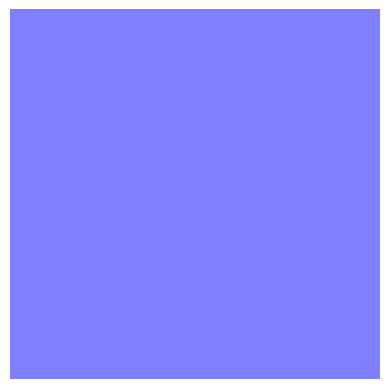

In [19]:
import matplotlib.colors as mcolors
import numpy as np

def adjust(color, factor):
    rgb = np.array(mcolors.to_rgb(color))
    return np.clip(rgb * factor, 0, 1)
def mix_with_white(color, alpha):
    rgb = np.array(mcolors.to_rgb(color))
    return alpha * rgb + (1 - alpha) * np.ones(3)
COLORS = {
    # base hues
    'L_base': mcolors.to_rgb('#d62728'),  # matplotlib red
    'R_base': mcolors.to_rgb('#1f77b4'),  # matplotlib blue

    # lighter (all selective)
    'L_light': mix_with_white('red', 0.5),
    'R_light': mix_with_white('blue', 0.5),

    'L_extralight': mix_with_white('red', 0.3),
    'R_extralight': mix_with_white('blue', 0.3),

    # darker (subset / switched)
    'L_dark':  adjust('#d62728', 0.8),
    'R_dark':  adjust('#1f77b4', 0.8),
}

## SI

In [20]:
#Get mask selectivity measures at timepoint of maximum CR-CL value
activityThresh = 0.1 #minimum CR+CL
ciThrsh = 0.66 # maximum CI on the selectivity index (CR-CL)/(CR+CL)
selectivityData={}
for ak, anat in enumerate(anatKeys):
    allMasks = []
    allSmallEnough = []
    allSI = []
    allNums = []
    allDenoms = []
    
    for p, phase in enumerate(['pre','post']):       
        allCDs = np.hstack([allAnmCDs[anat][anm][phase] for anm in allAnmCDs[anat].keys()]) #boot, roi, time
        allCDDenoms = np.hstack([allAnmDenoms[anat][anm][phase] for anm in allAnmDenoms[anat].keys()]) #boot, roi, time
        allCDs[allCDDenoms<activityThresh]=np.NaN
        allCDNums = allCDs*allCDDenoms
        CI = np.nanpercentile(allCDs,[2.5,97.5], axis=0) #low,high x roi x time
        sis = np.nanmean(allCDs, axis = 0)
        allSI.append(sis)
        widths = abs(CI[1,:,:]-CI[0,:,:])
        nums=np.nanmean(allCDNums,axis=0)
        allNums.append(nums)
        denoms=np.nanmean(allCDDenoms,axis=0)
        allDenoms.append(denoms)
        CI_small_enough = np.logical_and(widths<ciThrsh, widths!=0)
                    
        # sensical_selective_masks = np.zeros(means.shape[0])
        sensical_selective_masks = np.zeros(denoms.shape[0])
        pMask = np.zeros_like(CI_small_enough)
        for roi in range(sis.shape[0]):
            if np.any(CI_small_enough[roi,:]):
                idx = np.nanargmax(np.abs(nums[roi,:]))
                if CI_small_enough[roi,idx]:
                    sensical_selective_masks[roi] = True
                    pMask[roi,:] = CI_small_enough[roi,:]
        allMasks.append(sensical_selective_masks)
        allSmallEnough.append(pMask)
    
    masks = np.vstack(allMasks)
    sis = np.dstack(allSI)
    denoms = np.dstack(allDenoms)
    nums = np.dstack(allNums)
    ase = np.dstack(allSmallEnough)

    origPs = masks[0,:].astype(bool)
    origSI = np.ones(origPs.shape[0])*np.NaN
    origSIS = sis[:,:,0]
    origDenom = np.ones(origPs.shape[0])*np.NaN
    origDenoms = denoms[:,:,0]
    origNum = np.ones(origPs.shape[0])*np.NaN
    origNums = nums[:,:,0]
    for roi in range(len(origPs)):
        if origPs[roi]:
            idx = np.nanargmax(np.abs(origNums[roi,:]))
            origSI[roi] = origSIS[roi,idx]
            origDenom[roi] = origDenoms[roi,idx]
            origNum[roi] = origNums[roi,idx]
            
    postPs = masks[1,:].astype(bool)
    postSI = np.ones(postPs.shape[0])*np.NaN
    postSIS = sis[:,:,1]
    postDenom = np.ones(postPs.shape[0])*np.NaN
    postDenoms = denoms[:,:,1]
    postNum = np.ones(postPs.shape[0])*np.NaN
    postNums = nums[:,:,1]
    for roi in range(len(postPs)):
        if postPs[roi]:
            idx = np.nanargmax(np.abs(postNums[roi,:]))
            postSI[roi] = postSIS[roi,idx]
            postDenom[roi] = postDenoms[roi,idx]
            postNum[roi] = postNums[roi,idx]

    for roi in range(len(origSI)):
        if np.isfinite(origSI[roi]) and np.isfinite(postSI[roi]):
            if np.nanmax(np.abs(postNums[roi,:]))>=np.nanmax(np.abs(origNums[roi,:])):
                idx = np.nanargmax(np.abs(postNums[roi,:]))
                if ase[roi,idx,0]:
                    origSI[roi]= origSIS[roi,idx]
                    origDenom[roi] = origDenoms[roi,idx]
                    origNum[roi] = origNums[roi,idx]
                else:
                    origSI[roi]= np.NaN
                    origDenom[roi] = np.NaN
                    origNum[roi] = np.NaN
                
            else:
                idx = np.nanargmax(np.abs(origNums[roi,:]))
                if ase[roi,idx,1]:
                    postSI[roi] = postSIS[roi,idx]
                    postDenom[roi] = postDenoms[roi,idx]
                    postNum[roi] = postNums[roi,idx]
                else:
                    postSI[roi] = np.NaN
                    postDenom[roi] = np.NaN
                    postNum[roi] = np.NaN
    aData={}
    aData['origSI'] = origSI
    aData['origDenom'] = origDenom
    aData['origNum'] = origNum    
    aData['postSI'] = postSI
    aData['postDenom'] = postDenom
    aData['postNum'] = postNum 
    selectivityData[anat]=aData

/home/range6-raid17/kerlinlab/envs/sled_env/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/tmp/ipykernel_184282/4228681133.py:18: RuntimeWarning: Mean of empty slice
  sis = np.nanmean(allCDs, axis = 0)
/tmp/ipykernel_184282/4228681133.py:21: RuntimeWarning: Mean of empty slice
  nums=np.nanmean(allCDNums,axis=0)


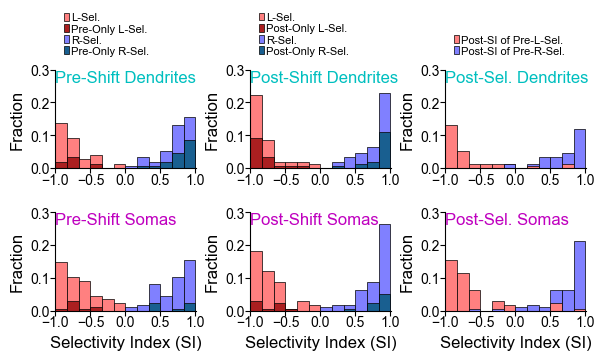

In [22]:
figName = 'Fig6_SI_alt.pdf'
niceAnatLabels = ['Dendrites', 'Somas']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
fontsize = 12
nBins = 12
linewidth = 0.5
nCols = 3
nRows = 2
hscalar = 2
vscalar = 1.5
CI = 68
ylims = [[0,0.3],[0,0.3],[0,0.3]]
xlim = [-1.01,1.01]
xticks = [-1,-0.5,0,0.5,1]
figSize = [nCols*hscalar,nRows*vscalar]
fig,axs=sled_general_tools.clean_subplots(nRows,nCols,figsize=figSize,constrained_layout =False)
plt.tight_layout()
# plt.subplots_adjust(wspace=0.1, hspace=0.2)
bins = np.linspace(-1.0001,1.0001,nBins+1)
binCenters = 0.5*(bins[:-1]+bins[1:])
binWidths  = np.diff(bins)
for ak, anat in enumerate(anatKeys):  
    origSI = selectivityData[anat]['origSI']
    postSI = selectivityData[anat]['postSI']
    selEver = np.logical_or(np.isfinite(postSI),np.isfinite(origSI))
    selBoth = np.logical_and(np.isfinite(postSI),np.isfinite(origSI))
    for p in range(3):
        ax=axs[ak,p]
        if p==0:
            sScores=origSI
            sigOnlyThisPhase = np.logical_and(np.isfinite(sScores),np.isnan(postSI))
        else:
            sScores=postSI
            sigOnlyThisPhase = np.logical_and(np.isfinite(sScores),np.isnan(origSI))   
        if p == 0:
            label = 'Pre-Shift'
            label1 = 'Pre-Only'
        elif p == 1:
            label = 'Post-Shift'
            label1 = 'Post-Only'
        elif p == 2:
            label = 'Post-Sel.'
            label1 = 'Post-Sel. of Pre-'
        if p!=2:
            for i in range(nBins):
                if i == nBins-1:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<=bins[i+1])
                else:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<bins[i+1])
        
                everyone = np.sum(guysInBin)/np.sum(selEver)
                onlySigNow = np.sum(guysInBin & sigOnlyThisPhase)/np.sum(selEver)
        
                if binCenters[i] < 0:
                    eC = COLORS['L_light']
                    oC = COLORS['L_dark']
                else:
                    eC = COLORS['R_light']
                    oC = COLORS['R_dark']
                if i == 0 or i == nBins - 1:
                    if i == 0:
                        side = 'L'
                    elif i == nBins - 1:
                        side = 'R'
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth,label = side+"-Sel.")
                    ax.bar(binCenters[i], onlySigNow, width=binWidths[i], color=oC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth,label = label1+" "+ side+"-Sel.")
                else:
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
                    ax.bar(binCenters[i], onlySigNow, width=binWidths[i], color=oC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
            ax.set_ylabel('Fraction',fontsize=fontsize)
            if ak == 1:
                ax.set_xlabel('Selectivity Index (SI)',fontsize=fontsize)
            ax.spines[['top','right']].set_visible(False)
            ax.set_ylim(ylims[p])
            ax.set_xlim(xlim)
            ax.set_xticks(xticks)
            ax.text(-1,ylims[p][1],label+" "+niceAnatLabels[ak],fontsize=fontsize,ha='left',va='top',color=aColors[ak])
            ax.tick_params(axis='both', which='major', labelsize=fontsize-2, pad = 0) #

            if ak == 0:
                ax.legend(frameon=False,fontsize=fontsize-4,loc='lower left',bbox_to_anchor=(0, 1.05),\
                          handlelength=0.5, markerscale=0.5, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

        else:
            wasL = np.logical_and(origSI<0, selBoth)
            wasR = np.logical_and(origSI>0, selBoth)
            sScores=copy.deepcopy(postSI)
            sScores[~selBoth]=np.NaN

            labeled = [0, 0]
            labeled1 = [0, 0]
            for i in range(nBins):
                if i == nBins-1:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<=bins[i+1])
                    side = 'R'
                    postIdx = 0
                else:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<bins[i+1])
                    side = 'L'
                    postIdx = 1
                everyone = np.sum(guysInBin)/np.sum(selEver)
                if binCenters[i] < 0:
                    weirdos = np.sum(guysInBin & wasR) / np.sum(selEver)
                    eC = COLORS['L_light']
                    wC = COLORS['R_light']
                    s1 = 'L'
                    s2 = 'R'
                    labeled[0]+=1
                    labeled1[postIdx]+=1
                else:
                    weirdos = np.sum(guysInBin & wasL) / np.sum(selEver)
                    eC = COLORS['R_light']
                    wC = COLORS['L_light']
                    s1 = 'R'
                    s2 = 'L'
                    labeled[1]+=1
                    labeled1[postIdx]+=1
                if (labeled[0] == 1) or (labeled[1] == 1):
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth,label = "Post-SI of Pre-"+s1+"-Sel.")
                    ax.bar(binCenters[i], weirdos, width=binWidths[i], color=wC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
                else:
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
                    ax.bar(binCenters[i], weirdos, width=binWidths[i], color=wC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
            # if p == 0:
            ax.set_ylabel('Fraction',fontsize=fontsize)
            if ak == 1:
                ax.set_xlabel('Selectivity Index (SI)',fontsize=fontsize)
            ax.spines[['top','right']].set_visible(False)
            ax.set_ylim(ylims[p])
            ax.set_xlim(xlim)
            ax.set_xticks(xticks)
            ax.text(-1,ylims[p][1],label+" "+niceAnatLabels[ak],fontsize=fontsize,ha='left',va='top',color=aColors[ak])
            ax.tick_params(axis='both', which='major', labelsize=fontsize-2, pad = 0) #
            if ak == 0:
                ax.legend(frameon=False,fontsize=fontsize-4,loc='lower left',bbox_to_anchor=(0, 1.05),\
                          handlelength=0.5, markerscale=0.5, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


dendrites n = 5.000 0.030 totalN = 169
somas n = 7.000 0.039 totalN = 180


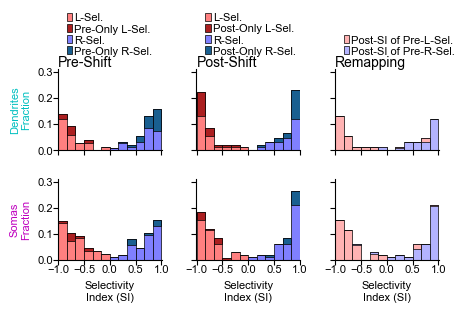

In [23]:
figName = 'Fig6_SI_alt2.pdf'
niceAnatLabels = ['Dendrites', 'Somas']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
fontsize = 8
nBins = 12
linewidth = 0.5
nCols = 3
nRows = 2
hscalar = 1.5
vscalar = 1.25
CI = 68
ylims = [[0,0.31],[0,0.31],[0,0.31]]
xlim = [-1.01,1.01]
xticks = [-1,-0.5,0,0.5,1]
yticks = [0,0.1,0.2,0.3]
figSize = [nCols*hscalar,nRows*vscalar]
fig,axs=sled_general_tools.clean_subplots(nRows,nCols,figsize=figSize,constrained_layout =False, sharex=True, sharey=True)
plt.tight_layout()
# plt.subplots_adjust(wspace=0.1, hspace=0.2)
bins = np.linspace(-1.0001,1.0001,nBins+1)
binCenters = 0.5*(bins[:-1]+bins[1:])
binWidths  = np.diff(bins)
for ak, anat in enumerate(anatKeys):  
    origSI = selectivityData[anat]['origSI']
    postSI = selectivityData[anat]['postSI']
    selEver = np.logical_or(np.isfinite(postSI),np.isfinite(origSI))
    selBoth = np.logical_and(np.isfinite(postSI),np.isfinite(origSI))
    for p in range(3):
        ax=axs[ak,p]
        if p==0:
            sScores=origSI
            sigOnlyThisPhase = np.logical_and(np.isfinite(sScores),np.isnan(postSI))
        else:
            sScores=postSI
            sigOnlyThisPhase = np.logical_and(np.isfinite(sScores),np.isnan(origSI))   
        if p == 0:
            label = 'Pre-Shift'
            label1 = 'Pre-Only'
        elif p == 1:
            label = 'Post-Shift'
            label1 = 'Post-Only'
        elif p == 2:
            label = 'Remapping'
            label1 = 'Post-Sel. of Pre-'
        if p!=2:
            for i in range(nBins):
                if i == nBins-1:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<=bins[i+1])
                else:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<bins[i+1])
        
                everyone = np.sum(guysInBin)/np.sum(selEver)
                onlySigNow = np.sum(guysInBin & sigOnlyThisPhase)/np.sum(selEver)
                offset = everyone - onlySigNow
                if binCenters[i] < 0:
                    eC = COLORS['L_light']
                    oC = COLORS['L_dark']
                else:
                    eC = COLORS['R_light']
                    oC = COLORS['R_dark']
                if i == 0 or i == nBins - 1:
                    if i == 0:
                        side = 'L'
                    elif i == nBins - 1:
                        side = 'R'
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth,label = side+"-Sel.")
                    ax.bar(binCenters[i], onlySigNow, bottom=offset, width=binWidths[i], color=oC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth,label = label1+" "+ side+"-Sel.")
                else:
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
                    ax.bar(binCenters[i], onlySigNow, bottom=offset, width=binWidths[i], color=oC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
            if p == 0:
                ax.set_ylabel(niceAnatLabels[ak] +'\nFraction',fontsize=fontsize,color=aColors[ak])
            if ak == 1:
                ax.set_xlabel('Selectivity\nIndex (SI)',fontsize=fontsize)
            ax.spines[['top','right']].set_visible(False)
            ax.set_ylim(ylims[p])
            ax.set_xlim(xlim)
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)
            if ak == 0:
                ax.text(-1,ylims[p][1],label,fontsize=fontsize+2,ha='left',va='bottom',color=(0,0,0))
            ax.tick_params(axis='both', which='major', labelsize=fontsize, pad = 0) #

            if ak == 0:
                ax.legend(frameon=False,fontsize=fontsize,loc='lower left',bbox_to_anchor=(0, 1.05),\
                          handlelength=0.5, markerscale=0.5, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

        else:
            wasL = np.logical_and(origSI<0, selBoth)
            wasR = np.logical_and(origSI>0, selBoth)

            switched_L_to_R = wasL & (postSI > 0)
            switched_R_to_L = wasR & (postSI < 0)
            switched = (switched_L_to_R)|(switched_R_to_L)
            print(anat, 'n =', f'{np.sum(switched):.03f}', f'{np.sum(switched)/len(switched):.03f}', 'totalN =', len(switched))
            
            sScores=copy.deepcopy(postSI)
            sScores[~selBoth]=np.NaN

            labeled = [0, 0]
            labeled1 = [0, 0]
            for i in range(nBins):
                if i == nBins-1:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<=bins[i+1])
                    side = 'R'
                    postIdx = 0
                else:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<bins[i+1])
                    side = 'L'
                    postIdx = 1
                everyone = np.sum(guysInBin)/np.sum(selEver)
                if binCenters[i] < 0:
                    weirdos = np.sum(guysInBin & wasR) / np.sum(selEver)
                    eC = COLORS['L_extralight']
                    wC = COLORS['R_extralight']
                    s1 = 'L'
                    s2 = 'R'
                    labeled[0]+=1
                    labeled1[postIdx]+=1
                else:
                    weirdos = np.sum(guysInBin & wasL) / np.sum(selEver)
                    eC = COLORS['R_extralight']
                    wC = COLORS['L_extralight']
                    s1 = 'R'
                    s2 = 'L'
                    labeled[1]+=1
                    labeled1[postIdx]+=1

                offset = everyone-weirdos
                if (labeled[0] == 1) or (labeled[1] == 1):
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth,label = "Post-SI of Pre-"+s1+"-Sel.")
                    ax.bar(binCenters[i], weirdos, bottom = offset, width=binWidths[i], color=wC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
                else:
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
                    ax.bar(binCenters[i], weirdos, bottom = offset, width=binWidths[i], color=wC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
            if p == 0:
                ax.set_ylabel(niceAnatLabels[ak] +'\nFraction',fontsize=fontsize,color=aColors[ak])
            if ak == 1:
                ax.set_xlabel('Selectivity\nIndex (SI)',fontsize=fontsize)
            ax.spines[['top','right']].set_visible(False)
            ax.set_ylim(ylims[p])
            ax.set_xlim(xlim)
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)
            if ak == 0:
                ax.text(-1,ylims[p][1],label,fontsize=fontsize+2,ha='left',va='bottom',color=(0,0,0))
            ax.tick_params(axis='both', which='major', labelsize=fontsize, pad = 0) #
            if ak == 0:
                ax.legend(frameon=False,fontsize=fontsize,loc='lower left',bbox_to_anchor=(0, 1.05),\
                          handlelength=0.5, markerscale=0.5, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


In [24]:
allSig = {}
allSI = {}
allDenom = {}
allNum = {}
nBoot = 10000
for ak, anat in enumerate(anatKeys):  
    SI = np.vstack([selectivityData[anat]['origSI'],selectivityData[anat]['postSI']])
    denom = np.vstack([selectivityData[anat]['origDenom'],selectivityData[anat]['postDenom']])
    num = np.vstack([selectivityData[anat]['origNum'],selectivityData[anat]['postNum']])
    masks = np.isfinite(SI)
    aSI = np.zeros([2,nBoot])
    aDenom = np.zeros([2,nBoot])
    aNum = np.zeros([2,nBoot])
    aNsig = np.zeros([2,nBoot])
    nAnms = len(np.unique(allAnmIdxs[anat]))
    for i in range(nBoot):
        bN=0
        maskIdx=[]
        for k in range(10000):
            if bN>=len(allAnmIdxs[anat]):
                break
            anm = np.random.choice(nAnms, 1)
            idx = (allAnmIdxs[anat]==anm).nonzero()[0]
            bN=bN+len(idx)
            maskIdx.append(idx)    
        maskIdx = np.hstack(maskIdx)[:len(allAnmIdxs[anat])]
        masksB = np.vstack([masks[:,x] for x in maskIdx]).T
        SIB = np.vstack([SI[:,x] for x in maskIdx]).T
        denomB = np.vstack([denom[:,x] for x in maskIdx]).T
        numB = np.vstack([num[:,x] for x in maskIdx]).T
        for p in range(2):
            finalMask = masksB[p,:]==1
            aSI[p,i] = np.nanmean(np.abs(SIB[p,:][finalMask]))
            aDenom[p,i] = np.nanmean(np.abs(denomB[p,:][finalMask]))
            aNum[p,i] = np.nanmean(np.abs(numB[p,:][finalMask]))
            aNsig[p,i] = np.nansum(finalMask)
    allSig[anat] = aNsig
    allSI[anat] = aSI
    allDenom[anat] = aDenom
    allNum[anat] = aNum
    
data = [allSig,allSI,allDenom,allNum] 
data2Plot=[]
for x in data:
    data2Plot.append([(x[anat][1]/x[anat][0]-1)*100 for anat in anatKeys])

# Sel. Masks mean: 11.948 std: 8.075 pval: 0.064600
# Sel. Masks mean: 6.782 std: 5.746 pval: 0.212200
anat p = 0.6879
Sel. Index [R-L]/[R+L] mean: 5.434 std: 2.149 pval: 0.024200
Sel. Index [R-L]/[R+L] mean: 11.155 std: 3.732 pval: 0.003000
anat p = 0.0875
Response [R+L] mean: -17.750 std: 5.007 pval: 0.000800
Response [R+L] mean: 12.056 std: 4.519 pval: 0.009000
anat p = 0.0
Sel. Mag. [R-L] mean: -8.875 std: 6.044 pval: 0.126800
Sel. Mag. [R-L] mean: 27.048 std: 6.044 pval: 0.000000
anat p = 0.0


Text(0.5, 1.0, 'Fig6_SI_perChange.pdf\n/export/general/pooledData/Calcium/JS_figsPanels/Fig6')

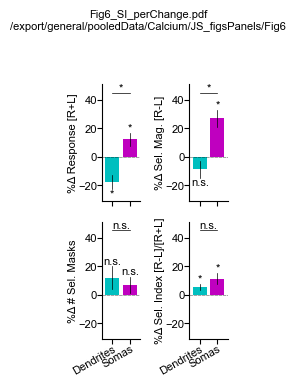

In [23]:
figName = 'Fig6_SI_perChange.pdf'
fontsize = 8
niceAnatLabels = ['Dendrites','Somas']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "boot. median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "boot. mean±SEM"
elif error == 'std':
    errorLabel = "boot. mean±SD"
linewidth = 0.5
figsize = [1.9,3.6]
alphas = [0.5,.8]
akLine = 45
ylim = [-31,51]
fig,axs=sled_general_tools.clean_subplots(2,2,figsize=figsize,facecolor='none',constrained_layout = False, sharex = True)

ylabels = [f'# Sel. Masks',
           f'Sel. Index [R-L]/[R+L]',
           f'Response [R+L]',
           f'Sel. Mag. [R-L]']
testLS = ':'
testDashes = (5,1)
testLW = linewidth
testColor = (0,0,0)
testAlpha = 0.5
testLine = 0
row = -1
col = -1
for i, data in enumerate(data2Plot):
    col+=1
    if col == 2:
        col = 0
        row+=1
    ax = axs[row,col]
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)

    for ak, anat in enumerate(anatKeys):

        mean = np.nanmean(data[ak],axis=0)
        med = np.nanmedian(data[ak],axis=0)
        std = np.nanstd(data[ak],axis=0, ddof = 1)
        sem = std / np.sqrt(data[ak].shape[0])
        low,high = np.nanpercentile(data[ak], [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        x = ak/4

        ax.bar(x,mainPlot, color = aColors[ak], width = 0.2, alpha = 1)
        ax.plot([x,x],[errorLow,errorHigh],color = (0,0,0),lw=linewidth)
    
        tail1 = np.sum(data[ak]<testLine)/np.sum(np.isfinite(data[ak]))
        tail2 = np.sum(data[ak]>testLine)/np.sum(np.isfinite(data[ak]))
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        pText = sled_stat_tools.pstar(pVal,inclP = False)

        print(ylabels[i], f'mean: {mainPlot:.03f}', f'std: {std:.03f}', f'pval: {pVal:03f}')

        if mainPlot<testLine:
            text_ypos = errorLow
            va='top'
        else:
            text_ypos = errorHigh
            va = 'bottom'

        ax.text(x,text_ypos,pText,fontsize=fontsize,ha='center',va=va)
    
    pVal = np.sum(data[0]>data[1])/nBoot
    pText = sled_stat_tools.pstar(pVal,inclP = False)
    # if pVal<0.05:
    #     pText = '*'
    # else:
    #     pText = 'n.s.'
    print('anat p = '+str(pVal))
    ax.set_ylim(ylim)
    ax.plot([0,0.25],[akLine,akLine], lw = linewidth, color = (0,0,0))
    ax.text(.125,akLine,pText,fontsize=fontsize,ha='center',va='bottom')

    ax.spines[['top','right']].set_visible(False)
    ax.set_ylabel("%Δ "+ ylabels[i],fontsize=fontsize,labelpad=0)
    ax.set_xlim([-0.15,0.4])
    ax.set_xticks([0,0.25])
    ax.set_xticklabels(niceAnatLabels,fontsize=fontsize-2,rotation=30,ha='right',va='top',rotation_mode='anchor')

    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page